In [ ]:
!pip install modelscope
!pip install staticvectors

In [ ]:
#模型下载
from modelscope import snapshot_download
model_dir = snapshot_download('NeuML/glove-6B', cache_dir="./")

In [1]:
from staticvectors import StaticVectors
# 1. 加载模型
model = StaticVectors("neuml/glove-6B/model.sqlite")

In [2]:
#2.用embeddings方法对词语进行嵌入
vec = model.embeddings(["hero", "queen"])
vec

array([[ 4.31766407e-02,  2.33069540e-02,  1.05229319e-01,
        -8.11982072e-02,  5.12200777e-02,  2.06980037e-02,
        -8.53811251e-02,  3.86564441e-02, -3.75520215e-02,
        -1.57819839e-02,  7.38045278e-02, -5.61238298e-02,
        -6.12243608e-02, -1.00361923e-02,  1.03855404e-02,
         6.70969792e-03,  4.08272627e-02, -6.60173565e-02,
         5.43729728e-02,  6.59346736e-02,  7.07012326e-02,
         3.34203567e-02,  1.12075747e-01,  4.55061788e-02,
        -1.23685410e-02, -2.39319117e-02, -1.69796707e-02,
         2.98177567e-02,  1.14076256e-01,  5.80185593e-03,
        -3.28483055e-02,  1.76443083e-02, -1.20545742e-03,
        -1.01413439e-01, -1.82444660e-01,  1.95654745e-03,
        -8.71534919e-03,  6.07465493e-02, -1.68490579e-02,
         1.73731626e-02,  5.95197805e-02, -5.77259204e-02,
         3.26796661e-02, -6.67481271e-02,  9.62252984e-03,
         8.32020398e-04,  3.22200412e-02, -7.71062223e-02,
         4.37619186e-03,  1.04255343e-02, -3.24614269e-0

In [3]:
import numpy as np

vecs = model.embeddings(["girl", "woman"])

vecs

array([[-0.08225908, -0.01461916, -0.09930598, -0.02449884, -0.04706354,
         0.0005833 , -0.01478612, -0.00804671, -0.05987542, -0.09231981,
         0.02826814,  0.01937101,  0.01693396,  0.04311786, -0.00474009,
        -0.04093612, -0.02850334, -0.06175698, -0.01225144, -0.05475222,
        -0.0428548 ,  0.16571888, -0.05833891,  0.00654706, -0.02655835,
        -0.06109781,  0.03148659, -0.02214382, -0.0038971 ,  0.05505859,
        -0.05228887,  0.00364055, -0.01535228,  0.01539081, -0.09639702,
         0.10374374, -0.06482223,  0.05658116,  0.02418629,  0.048043  ,
         0.07132566, -0.12097943,  0.02895825,  0.00611613,  0.00204804,
        -0.0125742 ,  0.07712968, -0.06769717, -0.00677389, -0.00221469,
         0.02501721, -0.05722795, -0.01771536,  0.07062317, -0.06915321,
        -0.06584347, -0.01863138, -0.02294688,  0.06441838, -0.10219022,
         0.03385091,  0.04349695,  0.05801863,  0.00343259, -0.03056283,
        -0.07607595,  0.0268384 , -0.0590213 , -0.0

In [4]:
#余弦相似度的计算
# a*b/|a||b|

cos_sim = np.dot(vecs[0], vecs[1])/(np.linalg.norm(vecs[0])*np.linalg.norm(vecs[1]))

cos_sim

0.7296419166293729

In [5]:
vecs2 = model.embeddings(["apple", "woman"])
cos_sim = np.dot(vecs2[0], vecs2[1])/(np.linalg.norm(vecs2[0])*np.linalg.norm(vecs2[1]))
cos_sim

0.09335044819907272

In [6]:
# 欧式距离
# |a-b|

dis1 = np.linalg.norm(vecs[0]-vecs[1])
dis1

0.7353340511231983

In [7]:
dis2 = np.linalg.norm(vecs2[0]-vecs2[1])
dis2

1.3465879487066021

In [8]:
# 可视化
from sklearn.manifold import TSNE

word_list =  ["boy", "girl", "woman", "man", "king", "queen", "water",
             "apple", "banana", "orange", "pear", "strawberry", "flower"
             ]

#1. 词嵌入
vecs = model.embeddings(word_list)

#2. 词降维
tsne = TSNE(n_components=2, random_state=42, perplexity=10)

vecs2_2d = tsne.fit_transform(vecs)

vecs2_2d

array([[ 15.70689   ,  12.860774  ],
       [  2.0396523 ,   2.1723297 ],
       [ 20.0075    , -11.442221  ],
       [  0.49276266, -19.226782  ],
       [ 38.798164  ,  26.046     ],
       [ 42.156635  ,   7.2485976 ],
       [-24.894163  ,  -3.3034966 ],
       [-11.758791  ,  29.452873  ],
       [-13.905776  ,  52.95913   ],
       [-31.716225  ,  20.242044  ],
       [  4.6506047 ,  40.142654  ],
       [-30.976955  ,  43.156116  ],
       [  9.016741  ,  59.8743    ]], dtype=float32)

C:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 35789 (\N{CJK UNIFIED IDEOGRAPH-8BCD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21521 (\N{CJK UNIFIED IDEOGRAPH-5411}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 35270 (\N{CJK UNIFIED IDEOGRAPH-89C6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda\Lib\site-packages\IPython\core\pylabtools.p

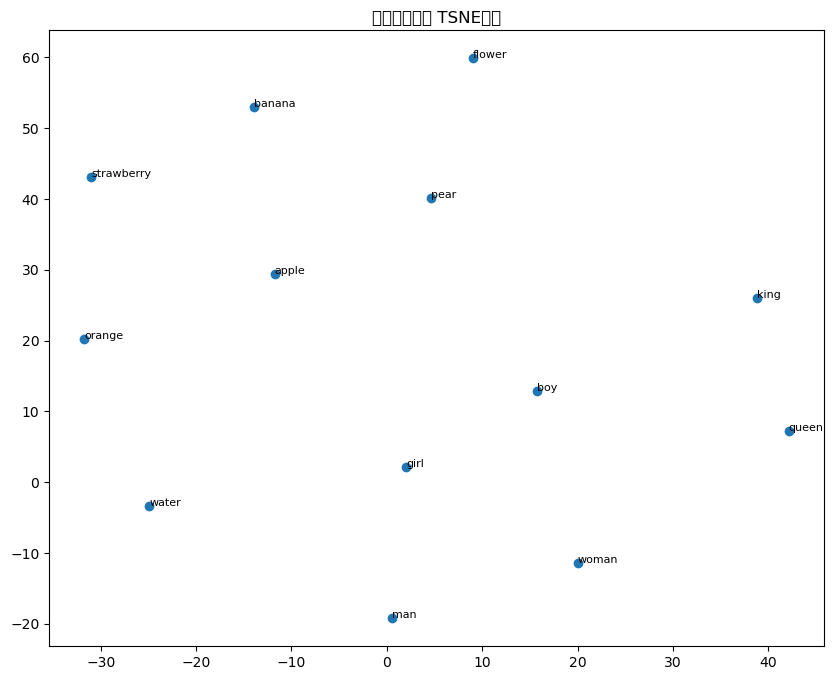

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.scatter(vecs2_2d[:,0], vecs2_2d[:,1])

for i,word in enumerate(word_list):
    plt.annotate(word, (vecs2_2d[i,0], vecs2_2d[i,1]), fontsize=8)

plt.title("词向量可视化 TSNE降维")
plt.show()